# Gaze Dynamics: Static vs. Moving Stimulus Error Analysis

### Overview
This notebook compares eye-tracking precision when interacting with stationary versus moving visual stimuli. It evaluates performance by matching the static and moving **stimulus** properties within the exact same environmental **frame of reference**.

### Visualized Data Summary

#### 1. Stimulus Motion Dynamics
* **Static Stimulus Baseline**: Measures directional tracking errors when the participant's gaze is fixed on stationary targets.
* **Moving Stimulus Performance**: Tracks eye-movement accuracy degradation when the exact same target behaves as a moving **stimulus**.

#### 2. Frame of Reference Comparisons
* **World-Stabilized Frame of Reference (`w1`, `w2`, `w3`)**: Compares tracking stability when the **stimulus** is anchored to fixed coordinates in the physical room.
* **Screen-Stabilized Frame of Reference (`s4`)**: Evaluates tracking variations when the **stimulus** moves relative to the display viewport.
* **Body-Stabilized Frame of Reference (`b5`)**: Examines accuracy drops when the **stimulus** coordinates shift relative to the participant's body movements.

#### 3. Error Metric and Dispersion
* **Cosine Similarity Vector Errors ($\degree$)**: Displays directional tracking deviations in absolute degrees of visual angle for each matching **frame of reference**.
* **Statistical Spread**: Renders side-by-side grouped bar charts with 95% Confidence Intervals to show whether a moving **stimulus** significantly increases tracking error compared to a static **stimulus**.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats.mstats import winsorize
import scipy.stats
import os

calibrate_with = 'cal' #choices=['cal', 'w1', 'w2', 'w3', 's4', 'b5']

In [5]:

moving_error_df_path = '../recalibrated_data/moving_target/error_df.csv'
static_error_df_path = '../recalibrated_data/static_target/error_df.csv'

if not (os.path.exists(moving_error_df_path) or os.path.exists(static_error_df_path)):
    exit()

# Ensure that the recalibrated dataset exists for all participants before computing error plots
%run ../python_scripts/recalibrate_data.py --type moving --with {calibrate_with}
%run ../python_scripts/recalibrate_data.py --type static --with {calibrate_with}

Starting execution. Total participants to process: 36


Overall Progress: 100%|██████████| 36/36 [00:00<00:00, 36011.20participant/s]



Script execution completed successfully!
Starting execution. Total participants to process: 36


Overall Progress: 100%|██████████| 36/36 [00:00<00:00, 70823.14participant/s]


Script execution completed successfully!


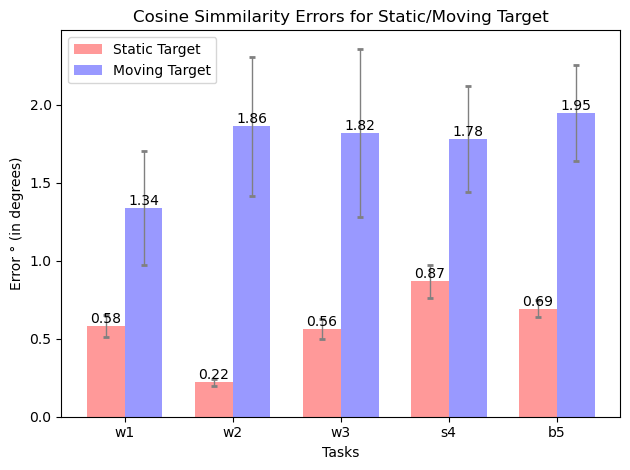

In [6]:

moving_error_df = pd.read_csv(moving_error_df_path, index_col=False)
static_error_df = pd.read_csv(static_error_df_path, index_col=False)
moving_error_df = moving_error_df[['w1_vec', 'w2_vec', 'w3_vec', 's4_vec', 'b5_vec']]
static_error_df = static_error_df[['w1_vec', 'w2_vec', 'w3_vec', 's4_vec', 'b5_vec']]
for column in static_error_df:
    winsorize(static_error_df[column], limits=(0.2,0.2), inplace=True)

xvals = range(len(moving_error_df.columns))
labels = [x[:-4] for x in static_error_df.columns]
# labels = labels[:-1]+['recalibrate']

x = np.arange(len(labels))

y1 = static_error_df.mean()
y1_std = static_error_df.std()/np.sqrt(static_error_df.shape[0])*1.96
y2 = moving_error_df.mean()
y2_std = moving_error_df.std()/np.sqrt(moving_error_df.shape[0])*1.96

opacity = 0.4
bar_width = 0.35

plt.xlabel('Tasks')
plt.ylabel('Error ° (in degrees)')

plt.xticks(range(len(y1)),labels)
bar1 = plt.bar(np.arange(len(y1)) - bar_width/2, y1, bar_width, yerr=y1_std,align='center', alpha=opacity, color='r', label='Static Target', error_kw=dict(ecolor='gray', lw=1, capsize=2, capthick=2))
bar2 = plt.bar(np.arange(len(y2)) + bar_width/2, y2, bar_width,yerr=y2_std, align='center', alpha=opacity, color='b', label='Moving Target',  error_kw=dict(ecolor='gray', lw=1, capsize=2, capthick=2))

# Add counts above the two bar graphs
for rect in bar1 + bar2:
    height = rect.get_height()
    plt.text(rect.get_x() + rect.get_width() / 2.0, height, f'{height:.2f}', ha='center', va='bottom')

plt.title("Cosine Simmilarity Errors for Static/Moving Target")
plt.legend()
plt.tight_layout()
plt.show()